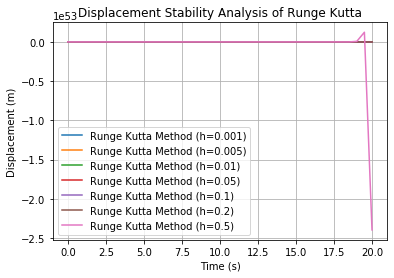

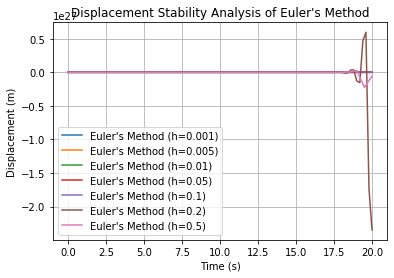

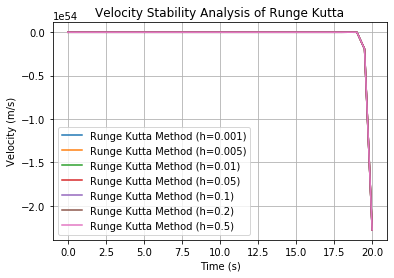

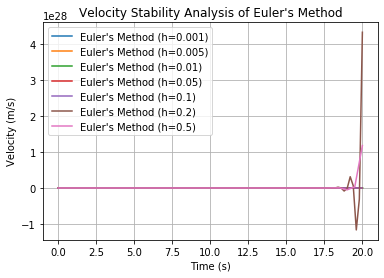

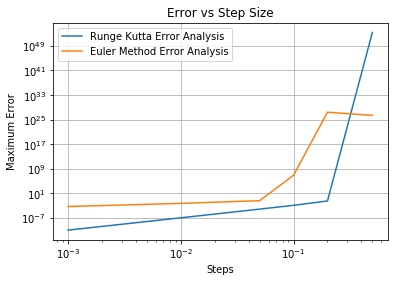

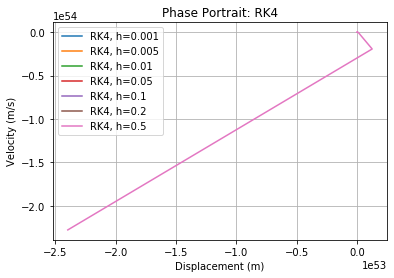

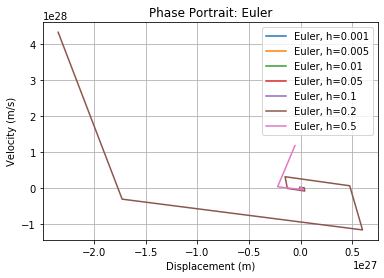

In [4]:
import numpy as np
import matplotlib.pyplot as plt

k = 35000 #label constants
c = 2900
t_start = 0    
t_end = 20     
m = 300
h = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5 ]  

def f(t, y):
    y1, y2 = y
    dy1_dt = y2
    dy2_dt =  -(c / m * y2) - (k / m * y1)
    return np.array([dy1_dt, dy2_dt]) #compute our second order differential equation into two first order equations

def euler_method(h, t_start, t_end):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    dy_values = np.zeros(len(t_values))    
    y_values[0] = 0.09 #initial values
    dy_values[0] = 0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        dy_n = dy_values[i - 1]        
        y_values[i] = y_n + h * dy_n
        dy_values[i] = dy_n + h * (-(c / m * dy_n) - (k / m * y_n))   
    return t_values, y_values, dy_values

def runge_kutta_4(f, t_start, t_end, h):
    rk_t_values = np.arange(t_start, t_end + h, h)
    rk_y_values = np.zeros((len(rk_t_values), 2))
    rk_y_values[0] = [0.09, 0]
    
    for a in range(1, len(rk_t_values)):
        rk_t = rk_t_values[a - 1]
        rk_y = rk_y_values[a - 1]
        k1 = h * f(rk_t, rk_y)
        k2 = h * f(rk_t + h / 2, rk_y + k1 / 2)
        k3 = h * f(rk_t + h / 2, rk_y + k2 / 2)
        k4 = h * f(rk_t + h, rk_y + k3)
        rk_y_values[a] = rk_y + (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return rk_t_values, rk_y_values [:, 0], rk_y_values[:, 1]

def real_solution(t): #chat gpt helped me find the analytical solution for the damped spring
    omega = np.sqrt(k/m)
    zeta = c / (2 * np.sqrt(k * m))
    d_omega = omega * np.sqrt(1 - zeta ** 2)
    yi = 0.09
    return yi * np.exp(-zeta * omega * t) * (np.cos(d_omega * t) + (zeta / np.sqrt(1 - zeta ** 2)) * np.sin(d_omega * t)) 
    
euler_err = []
rk_err = []

for size in h:
    e_t, e_y, e_v = euler_method(size, t_start, t_end) 
    r_t, r_y, r_v = runge_kutta_4(f, t_start, t_end, size)
    y_exact = real_solution(e_t)
    
    euler_err.append(np.max(np.abs(y_exact - e_y))) #compare the exact value to the euler value
    rk_err.append(np.max(np.abs(y_exact - r_y))) #compare the exact value to the runge kutta value

plt.figure()
for step in h:
    r_t, r_y, r_v = runge_kutta_4(f, t_start, t_end, step)
    plt.plot(r_t, r_y, label=f'Runge Kutta Method (h={step})')
    
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Displacement Stability Analysis of Runge Kutta')
plt.legend()
plt.grid(True)
plt.figure()

for steps in h:
    e_t, e_y, e_v = euler_method(steps, t_start, t_end)
    plt.plot(e_t, e_y, label=f'Euler\'s Method (h={steps})')
    
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Displacement Stability Analysis of Euler\'s Method')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for hs in h:
    r_t, r_y, r_v = runge_kutta_4(f, t_start, t_end, step)
    plt.plot(r_t, r_v, label=f'Runge Kutta Method (h={hs})')
    
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity Stability Analysis of Runge Kutta')
plt.legend()
plt.grid(True)
plt.figure()

for steps in h:
    e_t, e_y, e_v = euler_method(steps, t_start, t_end)
    plt.plot(e_t, e_v, label=f'Euler\'s Method (h={steps})')
    
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity Stability Analysis of Euler\'s Method')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.loglog(h, rk_err, label = f'Runge Kutta Error Analysis')
plt.loglog(h, euler_err, label = f'Euler Method Error Analysis')
plt.xlabel('Steps')
plt.ylabel('Maximum Error')
plt.title('Error vs Step Size')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
for step in h: #chat gpt helped me code the phase portraits 
    r_t, r_y, r_v = runge_kutta_4(f, t_start, t_end, step)
    plt.plot(r_y, r_v, label=f'RK4, h={step}')

plt.xlabel('Displacement (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Phase Portrait: RK4')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for step in h:
    e_t, e_y, e_v = euler_method(step, t_start, t_end)
    plt.plot(e_y, e_v, label=f'Euler, h={step}')

plt.xlabel('Displacement (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Phase Portrait: Euler')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
'''''
The code is simulating a car suspension system while driving over a speed bump. This is modeled as a damping mechanical system 
governing equation: my’’ + cy’ +ky = 0. We utilize this second-order differential equation to get two first order equations. 
These equations are dy1/dt = y2 and dy2/dt = -(c/m) * y2 - (k/m) * y1. The mass of the car is 1200 kg, however, due to the 
vehicle being a quarter car model, we divide by four to get 300 kg for the equation. The spring constant for the suspension 
system is 35,000 N/m and the damping coefficient is 2900 N * s / m. These values are taken from x-engineer.org 
(X-Engineer, n.d.), a website that provides many real world problems for automotive engineers. Finally, yi is 0.09 m because 
the average speed bump in America is around that height (National Association of City Transportation Officials, n.d.) and y’i is
0 due to the maximum compression before oscillating to return to equilibrium. The Euler method calculates position and velocity 
using current values from the ODEs and from step sizes. It is faster but less accurate especially for bigger step sizes. The 
Runge Kutta method calculates values utilizing estimates between each step. It then calculates the average of these values which
ensures that it is more accurate for bigger step sizes than Euler’s method. When plotted, the Runge Kutta method is more stable 
than the Euler method, especially for bigger step sizes. For the most part, Runge Kutta also has a lower maximum error when 
plotted against the Euler method. This makes sense when looking at the way each of these methods estimate values. This same 
pattern also applies to the phase portraits of each method. For the phase portrait, a more stable graph should spiral to 
equilibrium (0,0). The graph for the Runge Kutta method displays a smooth and constant spiral toward equilibrium. The Euler 
phase portrait is more jagged and less constant, the spiral is further away from equilibrium. For larger step sizes the spiral 
is further away from the equilibrium point. All of these graphs display how both of these methods become unstable after a 
certain step size. This instability comes when the step size is too big for the method to simulate the system's behavior. This 
causes the method to overestimate at each step and blow up. For our example, when the method becomes unstable it shows that the 
energy in the system is increasing over time when it should be decreasing. With all of this in mind, the Runge Kutta method 
performed better than the Euler method for this problem and should be used for real world applications. It is more stable for 
larger step sizes when compared to the Euler method. The accuracy and stability make the additional computational cost that 
comes with the Runge Kutta method worth it. 

National Association of City Transportation Officials. (n.d.). Speed hump.
https://nacto.org/publication/urban-street-design-guide/street-design-elements/vertical-speed-control-elements/speed-hump/ 
X-Engineer. (n.d.). Vehicle suspension – modeling and simulation.
https://x-engineer.org/quarter-car-suspension-modeling-simulation/ 
 

''''''

SyntaxError: EOF while scanning triple-quoted string literal (<ipython-input-20-3bbb07f5cb05>, line 7)